<a href="https://colab.research.google.com/github/2403a52026-lgtm/NLP.LabAssignments/blob/main/NLP_LAB_04_2403a52026_B_02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [14]:
import pandas as pd # Used for data manipulation and analysis, especially with DataFrames
import re # Used for regular expressions, helpful for text cleaning
import nltk # Natural Language Toolkit, a library for working with human language data
import spacy # Advanced Natural Language Processing library (though not used in subsequent cells here)
import matplotlib.pyplot as plt # Used for creating static, animated, and interactive visualizations in Python
from sklearn.feature_extraction.text import TfidfVectorizer # Used for converting a collection of raw documents to a matrix of TF-IDF features
from wordcloud import WordCloud # Used for generating word cloud visualizations

In [15]:
df = pd.read_csv("tweets.csv")   # Reads the 'tweets.csv' file into a pandas DataFrame
df = df[['text', 'airline_sentiment']] # Selects only the 'text' and 'airline_sentiment' columns from the DataFrame
df.head() # Displays the first 5 rows of the DataFrame to quickly inspect the data

,text,airline_sentiment
0,"Flight delayed again, very bad service",negative
1,Worst airline experience ever,negative
2,Seats were uncomfortable and staff was rude,negative
3,"I love this airline, great service!",positive
4,"Average flight, nothing special",neutral


In [16]:
nltk.download('stopwords') # Downloads the NLTK stopwords corpus
nltk.download('punkt') # Downloads the NLTK 'punkt' tokenizer models, used for tokenization
nltk.download('punkt_tab') # Downloads the NLTK 'punkt_tab' tokenizer (if not already present)
from nltk.corpus import stopwords # Imports the stopwords corpus from NLTK
from nltk.tokenize import word_tokenize # Imports the word_tokenize function from NLTK for splitting text into words

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [17]:
stop_words = set(stopwords.words('english')) # Creates a set of English stop words for efficient lookup

def clean_text(text): # Defines a function to clean text data
    text = re.sub(r"http\S+", "", text)      # Removes URLs from the text using regular expressions
    text = re.sub(r"@\w+", "", text)          # Removes mentions (e.g., @username) from the text
    text = re.sub(r"#\w+", "", text)          # Removes hashtags (e.g., #hashtag) from the text
    text = re.sub(r"[^a-zA-Z\s]", "", text)   # Removes special characters, keeping only letters and spaces
    text = text.lower() # Converts all text to lowercase

    tokens = word_tokenize(text) # Tokenizes the text into individual words
    tokens = [word for word in tokens if word not in stop_words] # Removes stop words from the tokenized list

    return " ".join(tokens) # Joins the cleaned tokens back into a single string

In [18]:
df['cleaned_text'] = df['text'].apply(clean_text) # Applies the `clean_text` function to the 'text' column and stores the result in a new 'cleaned_text' column
df.head() # Displays the first 5 rows of the DataFrame, including the new 'cleaned_text' column

,text,airline_sentiment,cleaned_text
0,"Flight delayed again, very bad service",negative,flight delayed bad service
1,Worst airline experience ever,negative,worst airline experience ever
2,Seats were uncomfortable and staff was rude,negative,seats uncomfortable staff rude
3,"I love this airline, great service!",positive,love airline great service
4,"Average flight, nothing special",neutral,average flight nothing special


In [19]:
negative_tweets = df[df['airline_sentiment'] == 'negative'] # Filters the DataFrame to include only tweets with 'negative' sentiment
negative_corpus = negative_tweets['cleaned_text'].tolist() # Extracts the 'cleaned_text' column from the negative tweets and converts it to a list

In [20]:
vectorizer = TfidfVectorizer(max_features=20) # Initializes a TF-IDF vectorizer to extract up to 20 most important features (words)
tfidf_matrix = vectorizer.fit_transform(negative_corpus) # Fits the vectorizer to the negative tweets corpus and transforms it into a TF-IDF matrix

tfidf_df = pd.DataFrame( # Creates a pandas DataFrame from the TF-IDF matrix
    tfidf_matrix.toarray(), # Converts the sparse TF-IDF matrix to a dense array
    columns=vectorizer.get_feature_names_out() # Uses the feature names (words) extracted by the vectorizer as column names
) # Ends DataFrame creation

tfidf_df.head() # Displays the first 5 rows of the TF-IDF DataFrame

,airline,bad,cancelled,customer,delayed,ever,experience,flight,help,rude,ruined,seats,service,staff,trip,uncomfortable,worst
0,0.0,0.550329,0.000000,0.000000,0.550329,0.0,0.0,0.444002,0.000000,0.0,0.000000,0.0,0.444002,0.0,0.000000,0.0,0.0
1,0.5,0.000000,0.000000,0.000000,0.000000,0.5,0.5,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.5
2,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.5,0.000000,0.5,0.000000,0.5,0.000000,0.5,0.0
3,0.0,0.000000,0.000000,0.614189,0.000000,0.0,0.0,0.000000,0.614189,0.0,0.000000,0.0,0.495524,0.0,0.000000,0.0,0.0
4,0.0,0.000000,0.523358,0.000000,0.000000,0.0,0.0,0.422242,0.000000,0.0,0.523358,0.0,0.000000,0.0,0.523358,0.0,0.0


In [21]:
top_terms = tfidf_df.mean().sort_values(ascending=False) # Calculates the mean TF-IDF score for each term across all negative tweets and sorts them in descending order
top_terms # Displays the Series of top terms and their average TF-IDF scores

,0
service,0.187905
flight,0.173249
help,0.122838
customer,0.122838
delayed,0.110066
bad,0.110066
trip,0.104672
ruined,0.104672
cancelled,0.104672
airline,0.100000


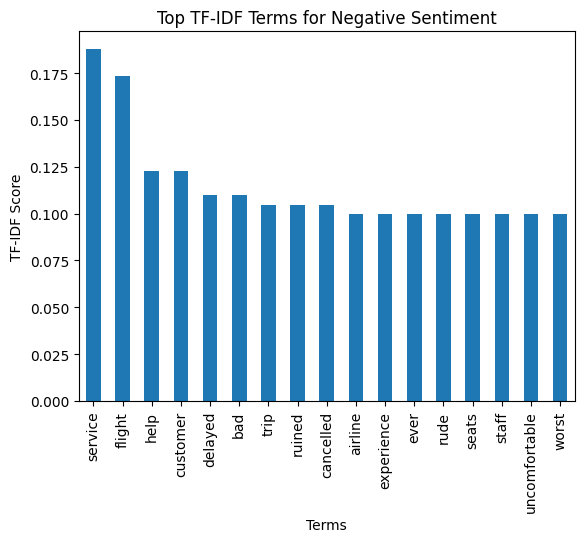

In [22]:
plt.figure() # Creates a new figure for the plot
top_terms.plot(kind='bar') # Generates a bar plot of the top TF-IDF terms
plt.title("Top TF-IDF Terms for Negative Sentiment") # Sets the title of the plot
plt.ylabel("TF-IDF Score") # Sets the label for the y-axis
plt.xlabel("Terms") # Sets the label for the x-axis
plt.show() # Displays the plot

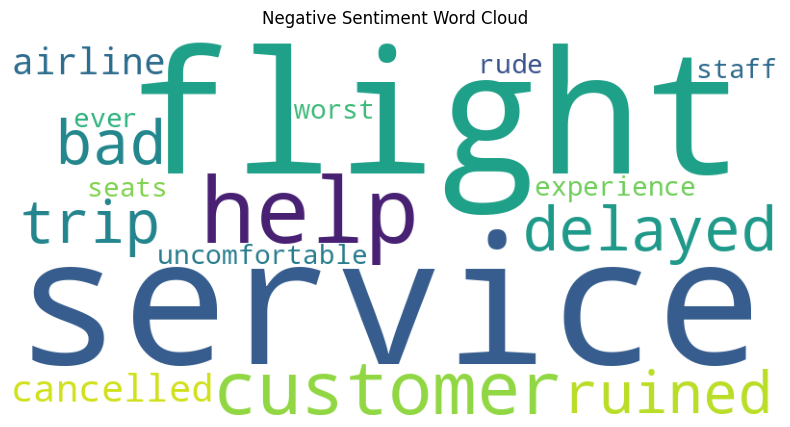

In [23]:
wordcloud = WordCloud( # Initializes a WordCloud object
    width=800, # Sets the width of the word cloud image
    height=400, # Sets the height of the word cloud image
    background_color='white' # Sets the background color of the word cloud
).generate_from_frequencies(top_terms) # Generates the word cloud from the frequencies of the top TF-IDF terms

plt.figure(figsize=(10,5)) # Creates a new figure for the word cloud with a specified size
plt.imshow(wordcloud) # Displays the generated word cloud image
plt.axis('off') # Turns off the axes for the plot
plt.title("Negative Sentiment Word Cloud") # Sets the title of the word cloud plot
plt.show() # Displays the word cloud